# Foundation Model
## Foundation models for information extraction

## 1. Precision@k

You are given the dataset with following samples and their prediction scores and ground truth labels
| Sample | Predicted scores           | Ground truth labels |
| ---    | -------------------------- | ------------------- |
| 1      | \[0.9, 0.1, 0.3, 0.6, 0.2] | \[1, 0, 0, 1, 0]    |
| 2      | \[0.2, 0.8, 0.7, 0.1, 0.4] | \[0, 1, 1, 0, 0]    |
| 3      | \[0.5, 0.2, 0.9, 0.4, 0.6] | \[0, 0, 1, 1, 0]    |
| 4      | \[0.1, 0.7, 0.2, 0.5, 0.8] | \[0, 1, 0, 0, 1]    |
| 5      | \[0.6, 0.9, 0.4, 0.3, 0.2] | \[1, 0, 0, 0, 0]    |
| 6      | \[0.3, 0.4, 0.8, 0.6, 0.1] | \[0, 0, 1, 1, 0]    |
| 7      | \[0.7, 0.2, 0.1, 0.9, 0.4] | \[0, 1, 0, 1, 0]    |
| 8      | \[0.4, 0.5, 0.3, 0.7, 0.2] | \[1, 0, 0, 1, 0]    |
| 9      | \[0.2, 0.6, 0.8, 0.3, 0.9] | \[0, 1, 1, 0, 1]    |
| 10     | \[0.5, 0.3, 0.4, 0.7, 0.2] | \[0, 0, 0, 1, 0]    |

With $k=3$, compute $precision@3$ for each sample and mean $precision@3$ for the whole dataset.


In [ ]:
# Precision@3 Manual Calculation (Jupyter Notebook Format)
## Complete Step-by-Step Solution

### Understanding Precision@k
'''
Understanding Precision@k
Definition: Measures fraction of correct positive predictions in top k results
Formula:
Precision@k = (True Positives in top k predictions) / k

## Sample-by-Sample Calculation
sample 01:
Predicted Scores: [0.9, 0.1, 0.3, 0.6, 0.2]
Ground Truth:     [1, 0, 0, 1, 0]

Step 1: Sort scores descending → [0.9, 0.6, 0.3]
Step 2: Top 3 positions → [0, 3, 2]
Step 3: Corresponding labels → [1, 1, 0]
Step 4: True Positives = 2
Step 5: Precision@3 = 2/3 = 0.6667
'''
import numpy as np

def calculate_precision_at_k(pred_scores, true_labels, k=3):
    """Calculates Precision@k for a single sample"""
    top_k_indices = np.argsort(pred_scores)[::-1][:k]
    true_positives = sum(true_labels[i] for i in top_k_indices)
    return true_positives / k

# Dataset
data = [
    {"scores": [0.9, 0.1, 0.3, 0.6, 0.2], "truth": [1, 0, 0, 1, 0]},
    {"scores": [0.2, 0.8, 0.7, 0.1, 0.4], "truth": [0, 1, 1, 0, 0]},
    {"scores": [0.5, 0.2, 0.9, 0.4, 0.6], "truth": [0, 0, 1, 1, 0]},
    {"scores": [0.1, 0.7, 0.2, 0.5, 0.8], "truth": [0, 1, 0, 0, 1]},
    {"scores": [0.6, 0.9, 0.4, 0.3, 0.2], "truth": [1, 0, 0, 0, 0]},
    {"scores": [0.3, 0.4, 0.8, 0.6, 0.1], "truth": [0, 0, 1, 1, 0]},
    {"scores": [0.7, 0.2, 0.1, 0.9, 0.4], "truth": [0, 1, 0, 1, 0]},
    {"scores": [0.4, 0.5, 0.3, 0.7, 0.2], "truth": [1, 0, 0, 1, 0]},
    {"scores": [0.2, 0.6, 0.8, 0.3, 0.9], "truth": [0, 1, 1, 0, 1]},
    {"scores": [0.5, 0.3, 0.4, 0.7, 0.2], "truth": [0, 0, 0, 1, 0]}
]

# Calculate and display results
print(f"{'Sample':<8} {'Top 3 Positions':<18} {'Ground Truth':<15} {'TP':<5} {'Precision@3':<12}")
print("-"*65)

precisions = []
for i, sample in enumerate(data, 1):
    top_k = np.argsort(sample["scores"])[::-1][:3]
    tp = sum(sample["truth"][idx] for idx in top_k)
    precision = tp/3
    precisions.append(precision)

    print(f"{i:<8} {str(top_k):<18} {str([sample['truth'][idx] for idx in top_k]):<15} {tp:<5} {precision:.4f}")

# Final mean calculation
print("\n" + "="*65)
print(f"Mean Precision@3: {np.mean(precisions):.4f}")
print("="*65)

Sample   Top 3 Positions    Ground Truth    TP    Precision@3 
-----------------------------------------------------------------
1        [0 3 2]            [1, 1, 0]       2     0.6667
2        [1 2 4]            [1, 1, 0]       2     0.6667
3        [2 4 0]            [1, 0, 0]       1     0.3333
4        [4 1 3]            [1, 1, 0]       2     0.6667
5        [1 0 2]            [0, 1, 0]       1     0.3333
6        [2 3 1]            [1, 1, 0]       2     0.6667
7        [3 0 4]            [1, 0, 0]       1     0.3333
8        [3 1 0]            [1, 0, 1]       2     0.6667
9        [4 2 1]            [1, 1, 1]       3     1.0000
10       [3 0 2]            [1, 0, 0]       1     0.3333

Mean Precision@3: 0.5667


## 2. BERT: Multiclass Text Classification
we will use the BERT model for multiclass generation.

Dataset: **Conference**

The dataset contains 2,507 research paper titles, and have been manually classified into 5 categories (i.e. conferences) that can be downloaded from here: https://raw.githubusercontent.com/susanli2016/NLP-with-Python/master/data/title_conference.csv

### Tasks:
a. Using a BERT model for multiclass classification on the **Conference** dataset  (refer to Exercise 5 for an example using BERT for binary classification). Split the dataset using an 80:20 ratio for training and testing. You may choose any of the following pre-trained models: `bert-base-cased`, `bert-base-uncased`, `bert-large-uncased`, `bert-large-cased`

Suggested hyperparameters:
- Learning rate: 2e-5
- Batch size: 16
- Maximum sequence length: 256
- Number of epochs: 10

b. Training the model using 100 samples from the dataset.

c. Saving the trained model to a file named bert_conference_model.pt.

d. Plotting the training loss and accuracy during training.

e. Testing the model with at least three paper titles.

f. Evaluating the model on the test set (20% of the data) and report the classification performance.

g. Trying other pre-trained models such as distilbert-base-uncased or roberta-base, and comparing their performance with bert-base-uncased.

h. Experiment with training on more data, potentially using the entire dataset.


In [2]:
!pip install torch transformers pandas scikit-learn matplotlib openpyxl tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 35.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Training Loss: 0.0142
Training Accuracy: 0.9980

Epoch 9/10
----------


Training: 100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


Training Loss: 0.0078
Training Accuracy: 0.9990

Epoch 10/10
----------


Training: 100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


Training Loss: 0.0077
Training Accuracy: 0.9990


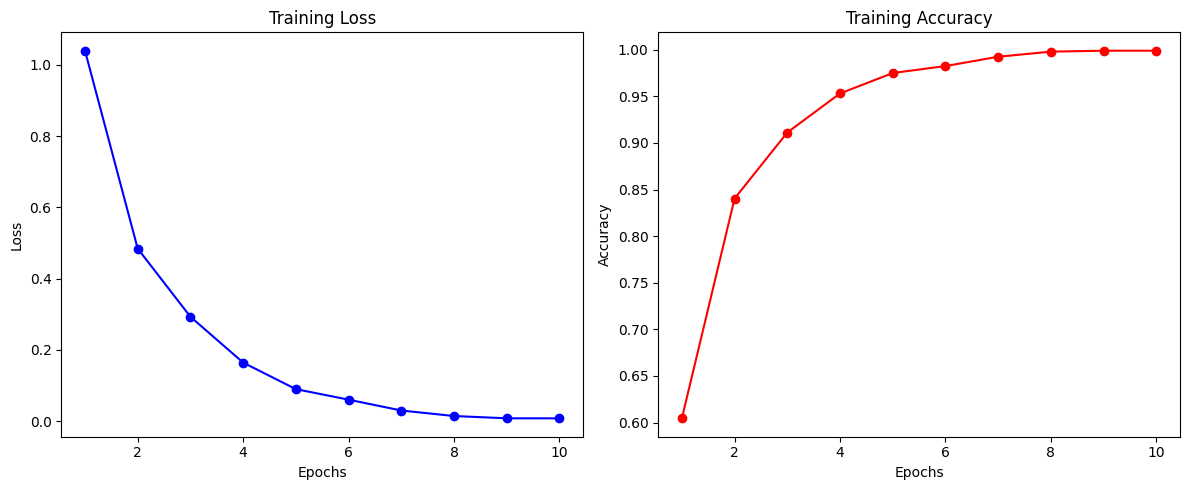

Model saved to bert_conference_model.pt


Evaluating: 100%|██████████| 32/32 [00:06<00:00,  4.66it/s]


Test Set Performance:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       108
           1       0.90      0.89      0.89       178
           2       0.82      0.73      0.77        67
           3       0.65      0.73      0.68        73
           4       0.68      0.66      0.67        76

    accuracy                           0.79       502
   macro avg       0.77      0.76      0.76       502
weighted avg       0.80      0.79      0.79       502

Accuracy: 0.7928

Sample Predictions:
Title: Deep Learning for Natural Language Understanding
Predicted Class: 4

Title: Blockchain Applications in Healthcare
Predicted Class: 0

Title: Cybersecurity in the Age of IoT
Predicted Class: 0



In [15]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Configuration
MODEL_NAME = 'bert-base-uncased'
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
MAX_LEN = 256
EPOCHS = 10

def load_csv_data(file_path, text_col='Title', label_col='Conference'):
    """Load dataset from CSV file"""
    df = pd.read_csv("./title_conference.csv")

    # Verify required columns exist
    if text_col not in df.columns or label_col not in df.columns:
        raise ValueError(f"CSV file must contain '{text_col}' and '{label_col}' columns")

    return df

def preprocess_data(df, text_col='Title', label_col='Conference', test_size=0.2):
    """Split data into train/test sets and encode labels"""
    train_texts, test_texts, train_labels, test_labels = train_test_split(
        df[text_col], df[label_col], test_size=test_size, random_state=SEED
    )

    if not np.issubdtype(train_labels.dtype, np.number):
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        train_labels = le.fit_transform(train_labels)
        test_labels = le.transform(test_labels)

    return train_texts, test_texts, train_labels, test_labels

def tokenize_texts(texts, tokenizer, max_len=MAX_LEN):
    """Tokenize texts and create attention masks"""
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)

    return input_ids, attention_masks

def create_data_loaders(train_texts, train_labels, test_texts, test_labels, tokenizer):
    """Create PyTorch DataLoader objects"""
    train_inputs, train_masks = tokenize_texts(train_texts, tokenizer)
    test_inputs, test_masks = tokenize_texts(test_texts, tokenizer)

    train_labels = torch.tensor(train_labels)
    test_labels = torch.tensor(test_labels)

    train_data = TensorDataset(train_inputs, train_masks, train_labels)
    test_data = TensorDataset(test_inputs, test_masks, test_labels)

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=BATCH_SIZE)

    test_sampler = SequentialSampler(test_data)
    test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=BATCH_SIZE)

    return train_dataloader, test_dataloader

def train_model(model, train_dataloader, epochs=EPOCHS):
    """Train the BERT model"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)
    total_steps = len(train_dataloader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    train_loss = []
    train_accuracy = []

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')
        print('-' * 10)

        total_loss = 0
        total_correct = 0
        total_samples = 0

        model.train()

        for batch in tqdm(train_dataloader, desc="Training"):
            batch = tuple(t.to(device) for t in batch)
            b_input_ids, b_input_mask, b_labels = batch

            model.zero_grad()

            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            total_correct += torch.sum(preds == b_labels).item()
            total_samples += b_labels.size(0)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_loss = total_loss / len(train_dataloader)
        accuracy = total_correct / total_samples

        train_loss.append(avg_loss)
        train_accuracy.append(accuracy)

        print(f'Training Loss: {avg_loss:.4f}')
        print(f'Training Accuracy: {accuracy:.4f}')

    return train_loss, train_accuracy

def evaluate_model(model, test_dataloader):
    """Evaluate model on test set"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    predictions = []
    true_labels = []

    for batch in tqdm(test_dataloader, desc="Evaluating"):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask
            )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(b_labels.cpu().numpy())

    return predictions, true_labels

def predict_text(model, tokenizer, text):
    """Predict class for a single text input"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    encoded_dict = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
        truncation=True
    )

    input_ids = encoded_dict['input_ids'].to(device)
    attention_mask = encoded_dict['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    return torch.argmax(outputs.logits, dim=1).cpu().numpy()[0]

def main():
    # Load data
    csv_file = "/title_conference.csv"  # Update with your actual path
    df = load_csv_data(csv_file)

    # Preprocess and split data
    train_texts, test_texts, train_labels, test_labels = preprocess_data(df)
    num_classes = len(np.unique(train_labels))

    # Initialize tokenizer and model
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_classes,
        output_attentions=False,
        output_hidden_states=False
    )

    # Create data loaders
    train_dataloader, test_dataloader = create_data_loaders(
        train_texts, train_labels, test_texts, test_labels, tokenizer
    )

    # Train model
    train_loss, train_accuracy = train_model(model, train_dataloader)

    # Plot training metrics
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, EPOCHS+1), train_loss, 'b-o')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(range(1, EPOCHS+1), train_accuracy, 'r-o')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

    # Save model
    torch.save(model.state_dict(), 'bert_conference_model.pt')
    print("Model saved to bert_conference_model.pt")

    # Evaluate on test set
    predictions, true_labels = evaluate_model(model, test_dataloader)

    print("\nTest Set Performance:")
    print(classification_report(true_labels, predictions))
    print(f"Accuracy: {accuracy_score(true_labels, predictions):.4f}")

    # Test with sample paper titles
    sample_titles = [
        "Deep Learning for Natural Language Understanding",
        "Blockchain Applications in Healthcare",
        "Cybersecurity in the Age of IoT"
    ]

    print("\nSample Predictions:")
    for title in sample_titles:
        pred_class = predict_text(model, tokenizer, title)
        print(f"Title: {title}\nPredicted Class: {pred_class}\n")

if __name__ == "__main__":
    main()